# Lizard Classification Challenge - Deep Learning

**Team**
- *Sasha Sydorenko*
- *Jairo Nacurena*
- *Illia Kryvoruchko*

**Objective:**
Classify images of 7 lizard species using CNNs, Data Augmentation, and Transfer Learning.

## 1. Import Packages and Setup

In [2]:
# 1. IMPORT PACKAGES AND LIBRARIES
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Check TensorFlow version to ensure GPU/CPU is working
print("TensorFlow version:", tf.__version__)

# Set seeds for reproducibility (always the same results when running the notebook multiple times)
tf.keras.utils.set_random_seed(123)

TensorFlow version: 2.21.0


## 2. Exploratory Data Analysis (EDA)

Before feeding images to our neural network, we must understand our dataset. We will check the class distribution inside our `train` folder to see if our dataset is balanced or suffers from Class Imbalance.

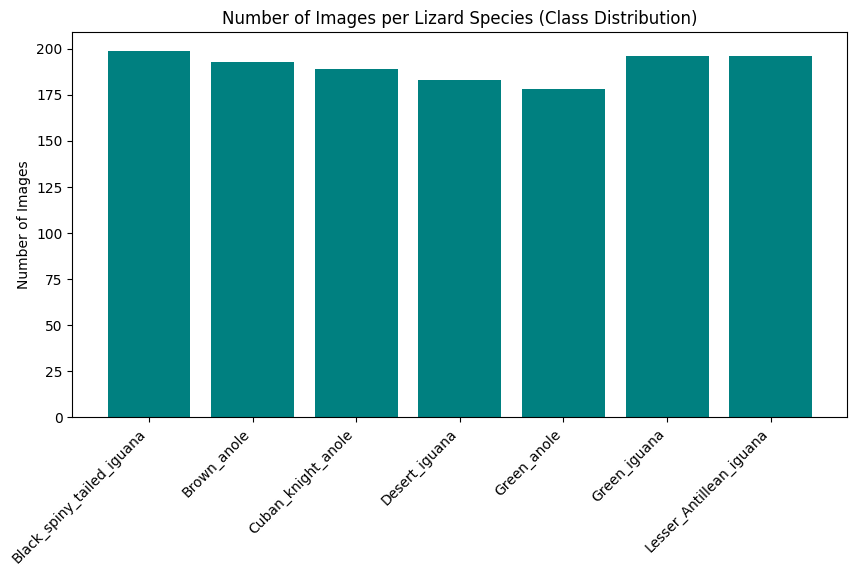

Total training images: 1334


In [3]:
# Path to training images
train_dir = 'train'

# Count images per class
classes = os.listdir(train_dir)
image_counts = {}

for lizard_class in classes:
    class_path = os.path.join(train_dir, lizard_class)
    if os.path.isdir(class_path): # Check if it's a folder
        image_counts[lizard_class] = len(os.listdir(class_path))

# Plot the distribution
plt.figure(figsize=(10, 5))
plt.bar(image_counts.keys(), image_counts.values(), color='teal')
plt.title("Number of Images per Lizard Species (Class Distribution)")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Number of Images")
plt.show()

# Print total
print(f"Total training images: {sum(image_counts.values())}")

## 3. Data Loading and Preprocessing

We will use Keras' `image_dataset_from_directory` to load our images efficiently in batches. We will resize all images to **224x224** pixels (the standard for most Transfer Learning models) and split our training folder into **80% training** and **20% validation**.

In [4]:
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

# Create Training Dataset (80%)
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Create Validation Dataset (20%)
val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Extract and save class names
class_names = train_ds.class_names
print("\nDetected Classes:", class_names)

# Optimize performance for loading data
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 1334 files belonging to 7 classes.
Using 1068 files for training.
Found 1334 files belonging to 7 classes.
Using 266 files for validation.

Detected Classes: ['Black_spiny_tailed_iguana', 'Brown_anole', 'Cuban_knight_anole', 'Desert_iguana', 'Green_anole', 'Green_iguana', 'Lesser_Antillean_iguana']


## 4. Baseline CNN Model & Data Augmentation

To prevent overfitting, we integrate Data Augmentation directly into our model pipeline. 
This is our **Baseline Model**: a simple Convolutional Neural Network built from scratch. We don't expect a massive accuracy yet, but this serves as our benchmark before applying Transfer Learning.

In [5]:
num_classes = len(class_names) # Should be 7

# 1. Data Augmentation Block
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# 2. Build the Baseline Model
model_baseline = keras.Sequential([
    keras.Input(shape=(224, 224, 3)),
    data_augmentation,
    layers.Rescaling(1./255), # Normalize pixel values between 0 and 1
    
    # Feature Extraction (Conv + Pooling)
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    # Classification Head
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3), # Prevent Overfitting
    layers.Dense(num_classes, activation='softmax') # Softmax for 7 classes
])

# 3. Compile the Model
model_baseline.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

model_baseline.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,939,335 (49.36 MB)

 Trainable params: 12,939,335 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 15s 334ms/step - accuracy: 0.1423 - loss: 2.2513 - val_accuracy: 0.1466 - val_loss: 1.9458
Epoch 2/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 11s 333ms/step - accuracy: 0.1564 - loss: 1.9468 - val_accuracy: 0.1579 - val_loss: 1.9406
Epoch 3/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 11s 322ms/step - accuracy: 0.1676 - loss: 1.9356 - val_accuracy: 0.1992 - val_loss: 1.9239
Epoch 4/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 11s 317ms/step - accuracy: 0.1816 - loss: 1.9177 - val_accuracy: 0.2331 - val_loss: 1.8449
Epoch 5/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 11s 316ms/step - accuracy: 0.2228 - loss: 1.8720 - val_accuracy: 0.2256 - val_loss: 1.9027
Epoch 6/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 304ms/step - accuracy: 0.2463 - loss: 1.8563 - val_accuracy: 0.2444 - val_loss: 1.8513
Epoch 7/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 305ms/step - accuracy: 0.2790 - loss: 1.7983 - val_accuracy: 0.2782 - val_loss: 1.7964
Epoch 8/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 307ms/step - accuracy: 0.2809 - loss: 1.7795 - val_accu

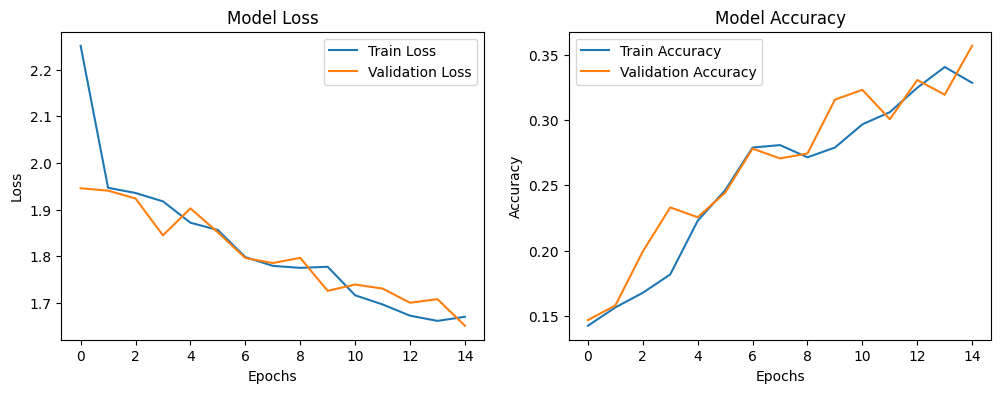

In [6]:
# Train the model (Let's start with 15 epochs)
epochs = 15
history = model_baseline.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

# Plotting function (Stef loves this)
def plotLosses(history):
    plt.figure(figsize=(12, 4))
    
    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.show()

plotLosses(history)